In [ ]:
# Basic Libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

#Import necessary Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

Dataset Link https://archive.ics.uci.edu/ml/datasets/Spambase

In [ ]:
#To create feature names automatically instead of typing 57 column names manually.
#This is necessary when datasets come without headers, which is common in UCI ML datasets.
#The columns will be listed ['f0','f1','f2','f3','f4', ... ,'f56']
#columns.append("spam") //This adds one more column at the end of the list.
#Resultant features ['f0','f1','f2', ... ,'f56','spam']

In [ ]:
# Column names from dataset documentation

columns = ["f"+str(i) for i in range(57)]
columns.append("spam")

data = pd.read_csv("/content/sample_data/spambase.data", header=None, names=columns)

print(data.head())


     f0    f1    f2   f3    f4    f5    f6    f7    f8    f9  ...   f48  \
0  0.00  0.64  0.64  0.0  0.32  0.00  0.00  0.00  0.00  0.00  ...  0.00   
1  0.21  0.28  0.50  0.0  0.14  0.28  0.21  0.07  0.00  0.94  ...  0.00   
2  0.06  0.00  0.71  0.0  1.23  0.19  0.19  0.12  0.64  0.25  ...  0.01   
3  0.00  0.00  0.00  0.0  0.63  0.00  0.31  0.63  0.31  0.63  ...  0.00   
4  0.00  0.00  0.00  0.0  0.63  0.00  0.31  0.63  0.31  0.63  ...  0.00   

     f49  f50    f51    f52    f53    f54  f55   f56  spam  
0  0.000  0.0  0.778  0.000  0.000  3.756   61   278     1  
1  0.132  0.0  0.372  0.180  0.048  5.114  101  1028     1  
2  0.143  0.0  0.276  0.184  0.010  9.821  485  2259     1  
3  0.137  0.0  0.137  0.000  0.000  3.537   40   191     1  
4  0.135  0.0  0.135  0.000  0.000  3.537   40   191     1  

[5 rows x 58 columns]


In [ ]:
print("Dataset Shape:", data.shape)
data.info()
data.describe()

Dataset Shape: (4601, 58)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4601 entries, 0 to 4600
Data columns (total 58 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   f0      4601 non-null   float64
 1   f1      4601 non-null   float64
 2   f2      4601 non-null   float64
 3   f3      4601 non-null   float64
 4   f4      4601 non-null   float64
 5   f5      4601 non-null   float64
 6   f6      4601 non-null   float64
 7   f7      4601 non-null   float64
 8   f8      4601 non-null   float64
 9   f9      4601 non-null   float64
 10  f10     4601 non-null   float64
 11  f11     4601 non-null   float64
 12  f12     4601 non-null   float64
 13  f13     4601 non-null   float64
 14  f14     4601 non-null   float64
 15  f15     4601 non-null   float64
 16  f16     4601 non-null   float64
 17  f17     4601 non-null   float64
 18  f18     4601 non-null   float64
 19  f19     4601 non-null   float64
 20  f20     4601 non-null   float64
 21  f21     460

,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,...,f48,f49,f50,f51,f52,f53,f54,f55,f56,spam
count,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,...,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000
mean,0.104553,0.213015,0.280656,0.065425,0.312223,0.095901,0.114208,0.105295,0.090067,0.239413,...,0.038575,0.139030,0.016976,0.269071,0.075811,0.044238,5.191515,52.172789,283.289285,0.394045
std,0.305358,1.290575,0.504143,1.395151,0.672513,0.273824,0.391441,0.401071,0.278616,0.644755,...,0.243471,0.270355,0.109394,0.815672,0.245882,0.429342,31.729449,194.891310,606.347851,0.488698
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.588000,6.000000,35.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.065000,0.000000,0.000000,0.000000,0.000000,2.276000,15.000000,95.000000,0.000000
75%,0.000000,0.000000,0.420000,0.000000,0.380000,0.000000,0.000000,0.000000,0.000000,0.160000,...,0.000000,0.188000,0.000000,0.315000,0.052000,0.000000,3.706000,43.000000,266.000000,1.000000
max,4.540000,14.280000,5.100000,42.810000,10.000000,5.880000,7.270000,11.110000,5.260000,18.180000,...,4.385000,9.752000,4.081000,32.478000,6.003000,19.829000,1102.500000,9989.000000,15841.000000,1.000000


In [ ]:
X = data.drop("spam", axis=1)   # features
y = data["spam"]                # target

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LogisticRegression(max_iter=500)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9239956568946797


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


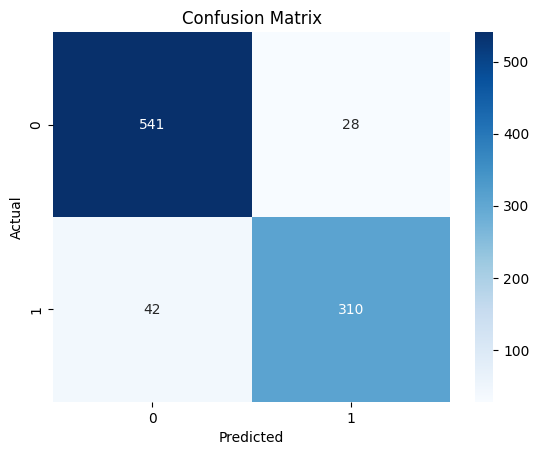

In [ ]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()